In [1]:
# read in info to make a figure on the inphared data 

In [1]:
# imports 
import pandas as pd
from collections import Counter
import glob
import seaborn as sns 
import matplotlib.pyplot as plt
from Bio import SeqIO
import re
import numpy as np 
from dna_features_viewer import GraphicFeature, GraphicRecord

In [2]:
# start by reading in inphared metadata 
inphared_metadata = pd.read_csv('../analysis_data/inphared_data/14Apr2025_data.tsv.gz', compression='gzip', sep='\t')
family_dict = dict(zip(inphared_metadata['Accession'], inphared_metadata['Family'])) 
class_dict = dict(zip(inphared_metadata['Accession'], inphared_metadata['Class'])) 

<ipython-input-2-78687b5a675b>:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  inphared_metadata = pd.read_csv('/home/grig0076/scratch/databases/millardlab_phages/April2025/14Apr2025_data.tsv.gz', compression='gzip', sep='\t')


In [3]:
# make dictionaries for the class and family 

In [8]:
# read in the inphared chunks 
phynteny_parts = glob.glob('../analysis_data/inphared_data/phynteny_output/*/*.tsv')
inphared_phynteny = pd.DataFrame() 

for p in phynteny_parts:  # correct this to show all the parts 
    this_phynteny = pd.read_csv(p, sep ='\t')
    inphared_phynteny = pd.concat([inphared_phynteny, this_phynteny])
    

In [9]:
# add family info 
inphared_phynteny['Family'] = [family_dict.get(i) for i in inphared_phynteny['phage']]
inphared_phynteny['Class'] = [class_dict.get(i) for i in inphared_phynteny['phage']]

In [26]:
# read in the sequences 
inphared_genomes = SeqIO.to_dict(SeqIO.parse('../analysis_data/inphared_data/14Apr2025_genomes.fa', 'fasta'))
inphared_genomes_length = pd.DataFrame({'ID': list(inphared_genomes.keys()), 'length': [len(i) for i in inphared_genomes.values()]})

In [51]:
# get the lengths of specific families listed in the manuscript 
steigviridae_id = inphared_phynteny[inphared_phynteny['Family'] == 'Steigviridae']['phage'].to_list()
steigviridae_lengths = inphared_genomes_length[inphared_genomes_length['ID'].isin(steigviridae_id)]['length']

# get the lengths of te peduoviridae
peduoviridae_id = inphared_phynteny[inphared_phynteny['Family'] == 'Peduoviridae']['phage'].to_list()
peduoviridae_lengths = inphared_genomes_length[inphared_genomes_length['ID'].isin(peduoviridae_id)]['length']

# get the lengths of the duneviridae
duneviridae_id = inphared_phynteny[inphared_phynteny['Family'] == 'Duneviridae']['phage'].to_list()
duneviridae_lengths = inphared_genomes_length[inphared_genomes_length['ID'].isin(duneviridae_id)]['length']

In [ ]:
rate_pharokka = []
rate_phynteny = [] 
num_genes_genome = [] 
phage = [] 
fully_annotated_phage = [] 

for p in list((set(inphared_phynteny['phage']))): 
    this_phage = inphared_phynteny[inphared_phynteny['phage'] == p]
    this_phage_pharokka = this_phage[this_phage['phrog_category'] != 'unknown function'] 
    this_phage_phynteny = this_phage[this_phage['phynteny_confidence'] > 0.8] 
    
    num_genes =  len(this_phage) 
    pharokka_genes = len(this_phage_pharokka)
    phynteny_genes = len(this_phage_pharokka) + len(this_phage_phynteny) 
    
    percent_pharokka = pharokka_genes*100/num_genes
    percent_phynteny = phynteny_genes*100/num_genes
    
    # ignore any phages that are fully annotated
    if num_genes != pharokka_genes: 
        rate_pharokka.append(percent_pharokka) 
        rate_phynteny.append(percent_phynteny) 
        phage.append(p)
        num_genes_genome.append(num_genes)
        
    else: 
        fully_annotated_phage.append(p)

In [ ]:
rate_df = pd.DataFrame({ 'pharokka rate': rate_pharokka , 'phynteny rate': rate_phynteny})
rate_df.index = phage
rate_df = rate_df.stack().reset_index() 
rate_df.columns = ['phage', 'method', 'rate'] 
rate_df['Family'] = [family_dict.get(p) for p in rate_df['phage']]
rate_df['Class'] = [class_dict.get(p) for p in rate_df['phage']]
#rate_df['increase'] = rate_df['phynteny rate'] - rate_df['pharokka rate']
# go and add other details to this for plotting 

In [ ]:
comparison_df = pd.DataFrame({'phage':phage, 'pharokka rate': rate_pharokka , 'phynteny rate': rate_phynteny})
comparison_df['increase'] = comparison_df['phynteny rate'] - comparison_df['pharokka rate']
comparison_df['Family'] = [family_dict.get(p) for p in comparison_df['phage']]
comparison_df['Class'] = [class_dict.get(p) for p in comparison_df['phage']]
comparison_df['num_genes'] = num_genes_genome
sns.displot(comparison_df['increase'])

In [ ]:
comparison_df[comparison_df['Family'] == 'Unclassified']['increase'].mean() 

In [794]:
per_family = pd.DataFrame.from_dict(Counter(comparison_df['Family']), orient='index')
familes_at_least10 = per_family[per_family[0] > 10].index.to_list()
familes_at_least15 = per_family[per_family[0] > 15].index.to_list()

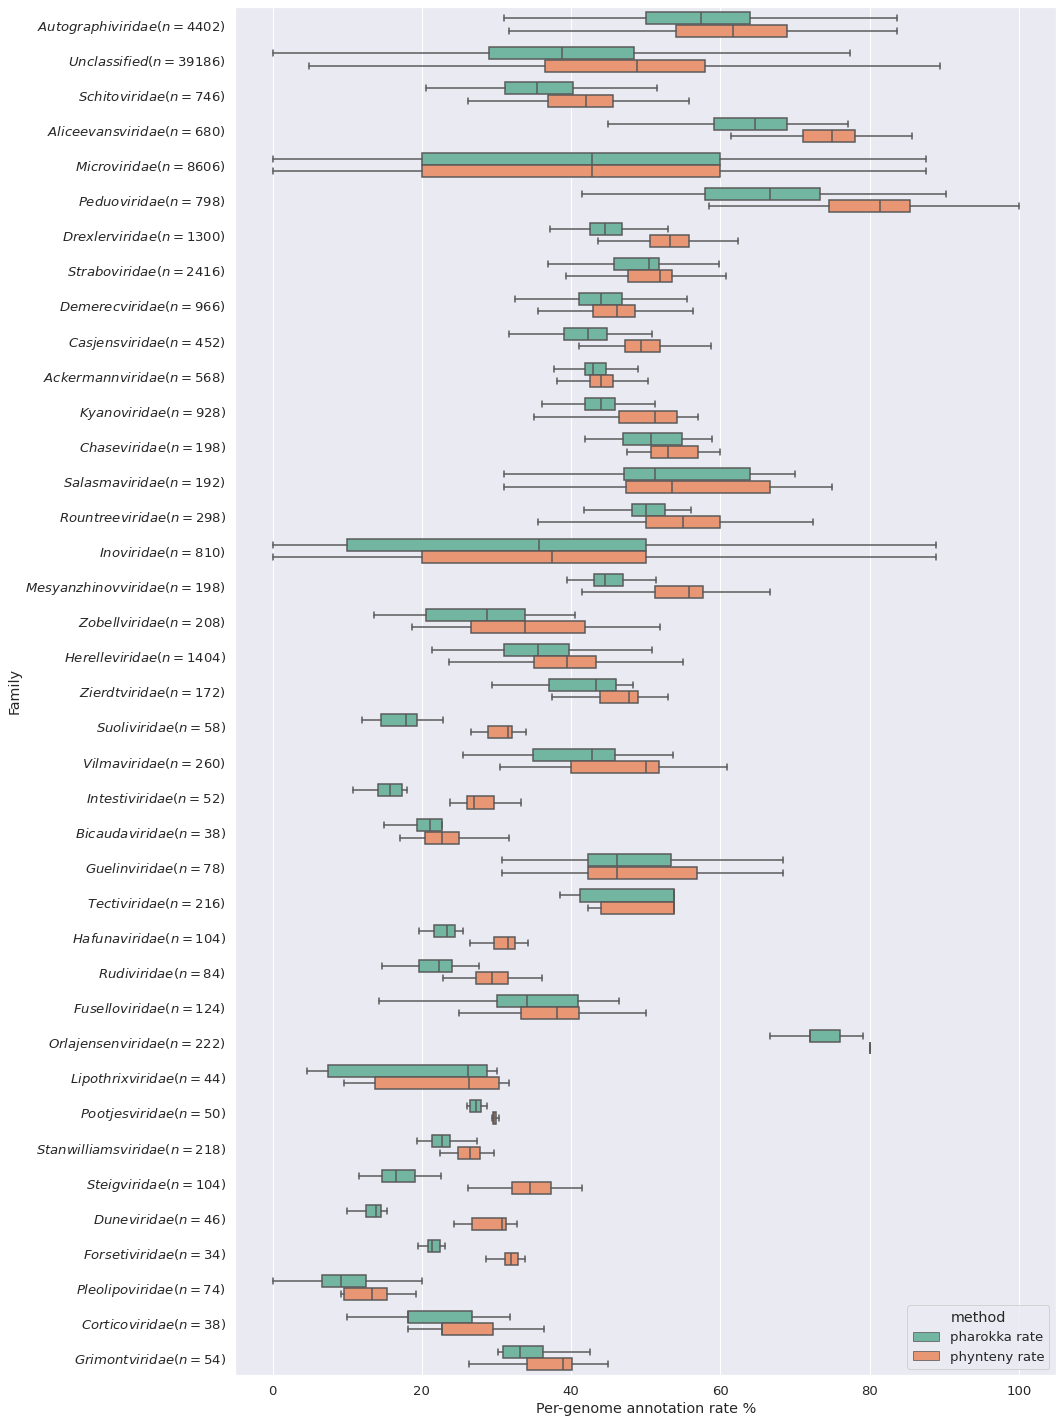

In [795]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute counts for each family
family_counts = rate_df['Family'].value_counts()

# Filter and annotate family names
filtered_families = rate_df['Family'].isin(familes_at_least15)
annotated_families = [
    f"{fam} (n={family_counts[fam]})" for fam in familes_at_least15
]

# Create mapping for renaming
family_name_map = dict(zip(familes_at_least15, annotated_families))

# Add annotated labels to a new column
rate_df['Family_annotated'] = rate_df['Family'].map(family_name_map)

# Plot with updated y-axis labels
#sns.set(font_scale=1.5, style='darkgrid')
plt.figure(figsize=(15, 20))
ax = sns.boxplot(
    data=rate_df[filtered_families],
    y='Family_annotated',
    x='rate',
    hue='method',
    palette=['#66c2a5', '#fc8d62'],
    showfliers=False,
    width=0.7,
    dodge=True,
)


# Apply italics to y-axis tick labels (which are family names)
new_labels = [label.get_text() for label in ax.get_yticklabels()]
ax.set_yticklabels([rf"$\it{{{label}}}$" for label in new_labels])

plt.xlabel('Per-genome annotation rate %')
plt.ylabel('Family')
plt.tight_layout()
plt.savefig('../figures/per_family_annotation.png')
plt.show()


In [797]:
comparison_df[comparison_df['Family'].isin(familes_at_least15)][['increase', 'Family']].groupby('Family').mean().sort_values('increase', ascending=False)

,increase
Family,
Steigviridae,17.621946
Duneviridae,15.918936
Peduoviridae,14.165143
Suoliviridae,12.958852
Intestiviridae,12.115237
Forsetiviridae,10.607856
Aliceevansviridae,10.598797
Mesyanzhinovviridae,9.399893
Unclassified,8.835462


## Add the percentage annotation to the tsv file

In [25]:
comparison_df[comparison_df['Family'] == 'Unclassified']

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
1,KU985094,52.500000,61.250000,8.750000,Unclassified,Caudoviricetes,80
4,NC_073327,30.487805,32.926829,2.439024,Unclassified,Caudoviricetes,82
5,DQ490056,26.530612,30.612245,4.081633,Unclassified,Caudoviricetes,49
7,PQ227241,23.901099,24.450549,0.549451,Unclassified,Unclassified,364
10,KT222941,34.848485,38.636364,3.787879,Unclassified,Caudoviricetes,132
...,...,...,...,...,...,...,...
33464,MT119361,28.244275,39.694656,11.450382,Unclassified,Caudoviricetes,131
33465,MK448863,47.916667,68.750000,20.833333,Unclassified,Caudoviricetes,48
33466,KC595515,45.833333,57.291667,11.458333,Unclassified,Caudoviricetes,96
33473,OQ326580,36.842105,41.052632,4.210526,Unclassified,Caudoviricetes,95


In [643]:
# Create the iTOL-style annotation file
annotation_lines = [
    "# This annotation file produces a stacked bar chart showing two values for each node.",
    "DATASET_MULTIBAR",
    "SEPARATOR TAB",
    "FIELD_LABELS	f1	f2",
    "FIELD_COLORS	#000000	#FF0000",
    "DATASET_LABEL   Viral Annotations",
    "DATA"
]

# Iterate through the DataFrame to build the data for the stacked bars
for index, row in comparison_df.iterrows():
    annotation_lines.append(f"{row['phage']}\t{row['pharokka rate']}\t{row['increase']}")

# Save the annotation file for iTOL
with open("../analysis_data/inphared_data/stacked_bar_chart_annotation_black_red.txt", "w") as file:
    file.write("\n".join(annotation_lines))


In [678]:
# for itol also make a file with the colors 
existing_colors = pd.read_csv('../analysis_data/inphared_data/itol/14Apr2025_itol_family_annotations_microviridae.txt', skiprows=23, sep = '\t', header=None)

dRep_genomes = glob.glob('../analysis_data/inphared_data/dereplicated_genomes/*')
dRep_genomes = [re.split('/', g)[-1][:-6] for g in dRep_genomes]

dRep_family = [family_dict.get(g) for g in dRep_genomes]
dRep_df = pd.DataFrame({'genome': dRep_genomes, 'family': dRep_family})
dRep_df_known_family =  dRep_df[dRep_df['family'] != 'Unclassified'] 

# get the 10 most common families to give a color to 
top10_families = pd.DataFrame.from_dict(Counter(dRep_df_known_family['family']), orient='index').sort_values(0, ascending=False).iloc[:10]

In [655]:
new_colors = ['#8dd3c7', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5',
'#bc80bd', '#ccebc5', '#ffed6f']

color_dict = dict(zip(top10_families.index, new_colors))
color_dict['Unclassified'] = '#d9d9d9'

In [682]:
existing_colors[1] = ['#d9d9d9' if color_dict.get(e) == None else color_dict.get(e) for e in existing_colors_reindex['DATA']]

In [686]:
existing_colors.to_csv('../analysis_data/inphared_data/itol/14Apr2025_itol_family_annotations_microviridae_new_colors.txt', index =None, header=None, sep = '\t')

## Make some plots showing the genome annotation

In [693]:
## pick one from herelleviridae
comparison_df[comparison_df['Family'] == 'Herelleviridae'].sort_values('increase', ascending=False)

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
2916,OX463805,31.343284,41.791045,10.447761,Herelleviridae,Caudoviricetes,201
16970,MN854830,32.338308,42.786070,10.447761,Herelleviridae,Caudoviricetes,201
3375,AP018715,33.990148,43.842365,9.852217,Herelleviridae,Caudoviricetes,203
25099,AP009390,28.504673,38.317757,9.813084,Herelleviridae,Caudoviricetes,214
19297,AB609718,28.504673,38.317757,9.813084,Herelleviridae,Caudoviricetes,214
...,...,...,...,...,...,...,...
1325,OP559179,68.888889,68.888889,0.000000,Herelleviridae,Caudoviricetes,45
21666,KT319607,71.428571,71.428571,0.000000,Herelleviridae,Caudoviricetes,14
2566,KT319626,58.333333,58.333333,0.000000,Herelleviridae,Caudoviricetes,12
2049,KT319602,55.000000,55.000000,0.000000,Herelleviridae,Caudoviricetes,20


In [766]:
## pick one from herelleviridae
comparison_df[comparison_df['Family'] == 'Unclassified'].sort_values('increase', ascending=False)

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
16654,OR786373,24.000000,66.000000,42.000000,Unclassified,Caudoviricetes,50
17290,MK757448,16.666667,55.555556,38.888889,Unclassified,Caudoviricetes,18
2503,NC_073597,16.666667,55.555556,38.888889,Unclassified,Caudoviricetes,18
27430,PQ571285,24.489796,63.265306,38.775510,Unclassified,Unclassified,49
9944,OY725315,25.714286,62.857143,37.142857,Unclassified,Caudoviricetes,35
...,...,...,...,...,...,...,...
24150,PP583598,42.857143,42.857143,0.000000,Unclassified,Unclassified,7
4016,OP999020,18.181818,18.181818,0.000000,Unclassified,Unclassified,22
23462,OR621025,50.000000,50.000000,0.000000,Unclassified,Faserviricetes,12
20800,OR464710,37.878788,37.878788,0.000000,Unclassified,Caudoviricetes,132


In [711]:
## pick one from herelleviridae
comparison_df[comparison_df['Family'] == 'Inoviridae'].sort_values('increase', ascending=False)

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
17617,KJ619459,40.000000,70.000000,30.000000,Inoviridae,Faserviricetes,10
2540,MF155889,40.000000,70.000000,30.000000,Inoviridae,Faserviricetes,10
5689,OX639564,9.090909,36.363636,27.272727,Inoviridae,Faserviricetes,11
6316,NC_015209,40.000000,66.666667,26.666667,Inoviridae,Faserviricetes,15
14962,HQ224500,40.000000,66.666667,26.666667,Inoviridae,Faserviricetes,15
...,...,...,...,...,...,...,...
13632,NC_001418,44.444444,44.444444,0.000000,Inoviridae,Faserviricetes,9
13631,NC_001332,87.500000,87.500000,0.000000,Inoviridae,Faserviricetes,8
13571,MW202882,33.333333,33.333333,0.000000,Inoviridae,Faserviricetes,9
13529,MW202766,12.500000,12.500000,0.000000,Inoviridae,Faserviricetes,8


In [720]:
## pick one from herelleviridae
comparison_df[comparison_df['Family'] == 'Autographiviridae'].sort_values('increase', ascending=False)

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
11100,NC_029092,40.000000,56.000000,16.000000,Autographiviridae,Caudoviricetes,50
22762,KY316062,50.000000,65.217391,15.217391,Autographiviridae,Caudoviricetes,46
26927,OR420748,35.185185,50.000000,14.814815,Autographiviridae,Caudoviricetes,54
6500,ON170184,45.614035,59.649123,14.035088,Autographiviridae,Caudoviricetes,57
20388,KT381879,42.000000,56.000000,14.000000,Autographiviridae,Caudoviricetes,50
...,...,...,...,...,...,...,...
28660,OQ860972,62.500000,62.500000,0.000000,Autographiviridae,Caudoviricetes,48
5095,PQ336914,62.745098,62.745098,0.000000,Autographiviridae,Caudoviricetes,51
12635,NC_023736,44.444444,44.444444,0.000000,Autographiviridae,Caudoviricetes,54
20539,LN913017,62.000000,62.000000,0.000000,Autographiviridae,Caudoviricetes,50


In [729]:
## pick one from herelleviridae
comparison_df[comparison_df['Family'] == 'Peduoviridae'].sort_values('increase', ascending=False)

,phage,pharokka rate,phynteny rate,increase,Family,Class,num_genes
27832,CP025900,50.943396,81.132075,30.188679,Peduoviridae,Caudoviricetes,53
13722,NC_049342,50.943396,81.132075,30.188679,Peduoviridae,Caudoviricetes,53
27337,OK490414,61.538462,87.179487,25.641026,Peduoviridae,Caudoviricetes,39
1257,MK034952,55.319149,80.851064,25.531915,Peduoviridae,Caudoviricetes,47
30009,NC_048109,55.319149,80.851064,25.531915,Peduoviridae,Caudoviricetes,47
...,...,...,...,...,...,...,...
20491,ON470606,71.111111,75.555556,4.444444,Peduoviridae,Caudoviricetes,45
26919,PP516623,90.000000,92.500000,2.500000,Peduoviridae,Caudoviricetes,40
11253,PP516624,90.000000,92.500000,2.500000,Peduoviridae,Caudoviricetes,40
5866,PP475179,85.365854,87.804878,2.439024,Peduoviridae,Caudoviricetes,41


In [703]:
colors1 = ['#f8f8ff', '#DDDDDD', '#CC6677','#DDCC77', '#332288',  '#117733', '#88CCEE',
                    '#882255', '#44AA99',  '#AA4499', '#999933'] 


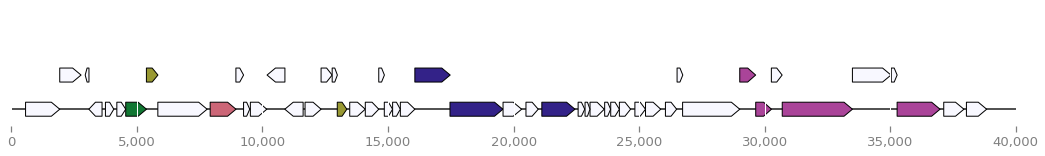

In [772]:
# Unclassified family Phage Aussie - pharokka annotations 

features = []
annotated = 0 
not_annotated = 0 

this_phage = inphared_phynteny[inphared_phynteny['phage'] == 'OR786373'].reset_index()

for i in range(len(this_phage)):
    
    
    category = this_phage['phrog_category'][i]
    #if category == 'unknown function':
    #    if  this_phage['phynteny_confidence'][i] > 0.8: 
    #        category = this_phage['phynteny_category'][i] 
    #        print(category)
    
    label = ''
    c = colors1[0]
    
    if category == 'integration and excision': 
        c = colors1[2]
        annotated+=1
    elif category == 'connector': 
        c = colors1[3]
        annotated+=1
    elif category == 'head and packaging': 
        c = colors1[4] 
        annotated+=1
    elif category  == 'DNA, RNA and nucleotide metabolism': 
        c = colors1[5]
        annotated+=1
    elif category == 'lysis': 
        c = colors1[6]
        annotated+=1
    elif category == 'moron, auxiliary metabolic gene and host takeover': 
        c = colors1[7]
        annotated+=1
    elif category == 'others': 
        c = colors1[8]
        annotated+=1
    elif category == 'tail': 
        c = colors1[9]
        annotated+=1
    elif category == 'transcription regulation': 
        c = colors1[10]
        annotated+=1
    else: 
        not_annotated+=1
    
    strand=+1
    if this_phage['strand'][i] =='-': 
        strand=-1

 
    f = GraphicFeature(start = this_phage['start'][i], end = this_phage['end'][i], color=c, strand =strand) 
    features.append(f)

record = GraphicRecord(sequence_length=40000, features=features)
ax, _ = record.plot(figure_width=18)

# add in phanns to this figure once I get these annotations from Anca 

ax.figure.savefig('../figures/annotation_comparison_OR786373_pharokka.png', bbox_inches='tight')

moron, auxiliary metabolic gene and host takeover
transcription regulation
transcription regulation
transcription regulation
integration and excision
moron, auxiliary metabolic gene and host takeover
DNA, RNA and nucleotide metabolism
lysis
lysis
other
head and packaging
head and packaging
head and packaging
connector
connector
connector
connector
tail
tail
tail
tail


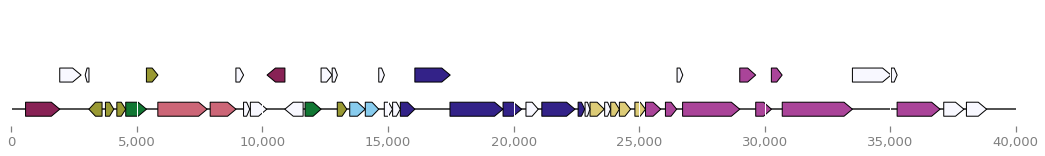

In [773]:
# Unclassified family Phage Aussie - phynteny annotations 

features = []
annotated = 0 
not_annotated = 0 

this_phage = inphared_phynteny[inphared_phynteny['phage'] == 'OR786373'].reset_index()

for i in range(len(this_phage)):
    
    
    category = this_phage['phrog_category'][i]
    if category == 'unknown function':
        if  this_phage['phynteny_confidence'][i] > 0.8: 
            category = this_phage['phynteny_category'][i] 
            print(category)
    
    label = ''
    c = colors1[0]
    
    if category == 'integration and excision': 
        c = colors1[2]
        annotated+=1
    elif category == 'connector': 
        c = colors1[3]
        annotated+=1
    elif category == 'head and packaging': 
        c = colors1[4] 
        annotated+=1
    elif category  == 'DNA, RNA and nucleotide metabolism': 
        c = colors1[5]
        annotated+=1
    elif category == 'lysis': 
        c = colors1[6]
        annotated+=1
    elif category == 'moron, auxiliary metabolic gene and host takeover': 
        c = colors1[7]
        annotated+=1
    elif category == 'others': 
        c = colors1[8]
        annotated+=1
    elif category == 'tail': 
        c = colors1[9]
        annotated+=1
    elif category == 'transcription regulation': 
        c = colors1[10]
        annotated+=1
    else: 
        not_annotated+=1
    
    strand=+1
    if this_phage['strand'][i] =='-': 
        strand=-1

 
    f = GraphicFeature(start = this_phage['start'][i], end = this_phage['end'][i], color=c, strand =strand) 
    features.append(f)

record = GraphicRecord(sequence_length=40000, features=features)
ax, _ = record.plot(figure_width=18)

# add in phanns to this figure once I get these annotations from Anca 

ax.figure.savefig('../figures/annotation_comparison_OR786373_phynteny.png', bbox_inches='tight')

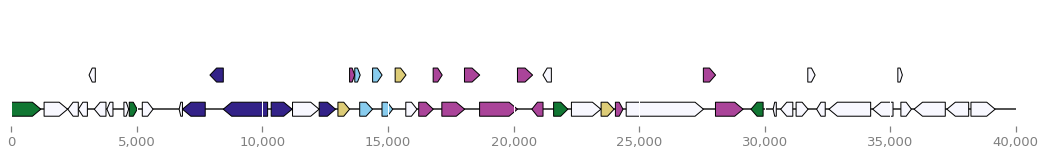

In [735]:
# Peduoviridae - Escherichia phage - pharokka annotations 

features = []
annotated = 0 
not_annotated = 0 

this_phage = inphared_phynteny[inphared_phynteny['phage'] == 'CP025900'].reset_index()

for i in range(len(this_phage)):
    
    
    category = this_phage['phrog_category'][i]
    #if category == 'unknown function':
    #    if  this_phage['phynteny_confidence'][i] > 0.8: 
    #        category = this_phage['phynteny_category'][i] 
    #        print(category)
    
    label = ''
    c = colors1[0]
    
    if category == 'integration and excision': 
        c = colors1[2]
        annotated+=1
    elif category == 'connector': 
        c = colors1[3]
        annotated+=1
    elif category == 'head and packaging': 
        c = colors1[4] 
        annotated+=1
    elif category  == 'DNA, RNA and nucleotide metabolism': 
        c = colors1[5]
        annotated+=1
    elif category == 'lysis': 
        c = colors1[6]
        annotated+=1
    elif category == 'moron, auxiliary metabolic gene and host takeover': 
        c = colors1[7]
        annotated+=1
    elif category == 'others': 
        c = colors1[8]
        annotated+=1
    elif category == 'tail': 
        c = colors1[9]
        annotated+=1
    elif category == 'transcription regulation': 
        c = colors1[10]
        annotated+=1
    else: 
        not_annotated+=1
    
    strand=+1
    if this_phage['strand'][i] =='-': 
        strand=-1

 
    f = GraphicFeature(start = this_phage['start'][i], end = this_phage['end'][i], color=c, strand =strand) 
    features.append(f)

record = GraphicRecord(sequence_length=40000, features=features)
ax, _ = record.plot(figure_width=18)

# add in phanns to this figure once I get these annotations from Anca 

ax.figure.savefig('../figures/annotation_comparison_CP025900_pharokka.png', bbox_inches='tight')

# Look for phrogs that are consistently predicted

In [41]:
best_inphared = inphared_phynteny[inphared_phynteny['phynteny_confidence'] > 0.8] 
predicted_phrog_counts = pd.DataFrame.from_dict(Counter(inphared_phynteny[inphared_phynteny['phynteny_confidence'] > 0.8]['phrog_id']), orient='index')

In [337]:
inphared_phold = pd.DataFrame()
phold_parts = glob.glob('../analysis_data/inphared_data/phold_output/*compare/phold_per_cds*.tsv')

for p in phold_parts: 
    this_phold = pd.read_csv(p, sep='\t')
    inphared_phold = pd.concat([inphared_phold, this_phold])
    
#inphared_phold['gene_num'] = [int(re.split( '_', p)[-1].replace('0', '')) -1  for p in inphared_phold['cds_id']]
inphared_phold['gene_num'] = [int(re.split('_', p)[-1].lstrip('0') or '0') - 1 for p in inphared_phold['cds_id']]
inphared_phold['ID'] = [inphared_phold['contig_id'].iloc[i] + '_' + str(inphared_phold['gene_num'].iloc[i]) for i in range(len(inphared_phold))]

In [349]:
good_phynteny = inphared_phynteny[inphared_phynteny['phynteny_confidence'] > 0.8]
good_phynteny.index = good_phynteny['ID']

inphared_phold.index = inphared_phold['ID']
phold_good_phynteny = inphared_phold.loc[set(good_phynteny.index).intersection(set(inphared_phold.index))]

<ipython-input-349-8dcba17d93ed>:5: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  phold_good_phynteny = inphared_phold.loc[set(good_phynteny.index).intersection(set(inphared_phold.index))]


In [355]:
phold_phynteny_compare = pd.DataFrame.from_dict({'phynteny': good_phynteny['phynteny_category'], 'phold': phold_good_phynteny.loc[good_phynteny.index]['function']})

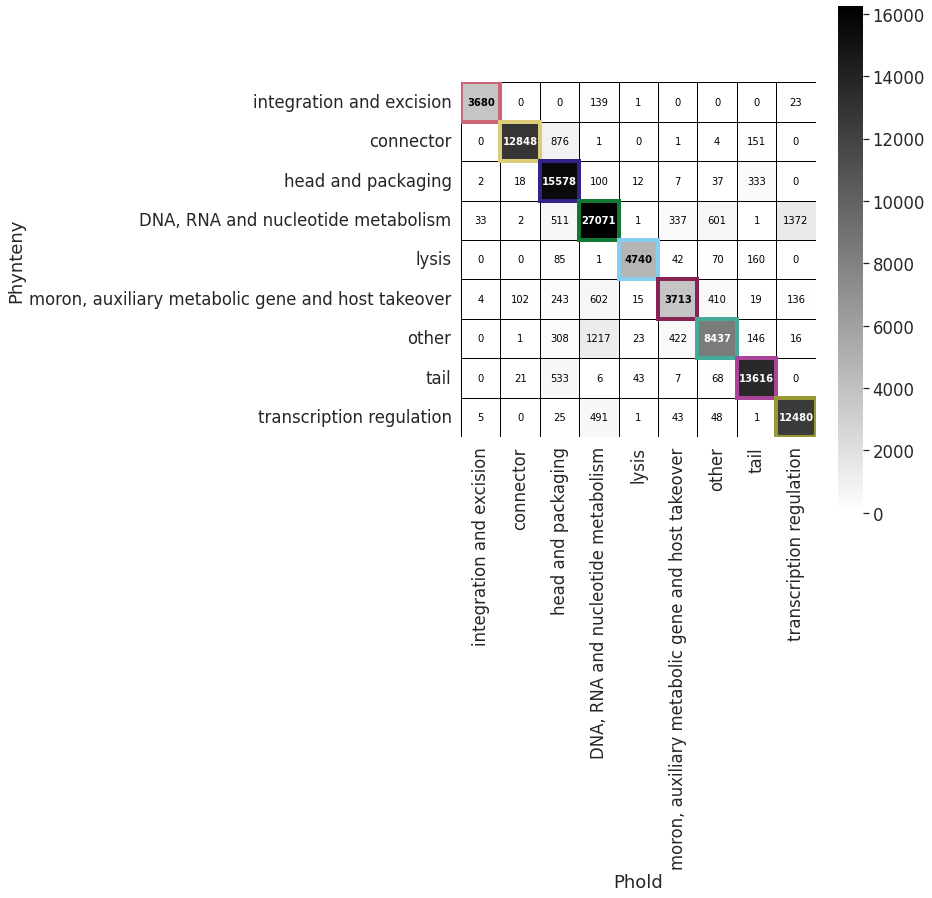

In [396]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix


df = phold_phynteny_compare
sns.set(font_scale=1.5)
# Define color palette and label order
colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']

labels_order = {
    3: 'DNA, RNA and nucleotide metabolism',
    1: 'connector',
    2: 'head and packaging',
    0: 'integration and excision',
    4: 'lysis',
    5: 'moron, auxiliary metabolic gene and host takeover',
    6: 'other',
    7: 'tail',
    8: 'transcription regulation',
}

ordered_labels = [labels_order[i] for i in sorted(labels_order.keys())]

# Create confusion matrix
cm = confusion_matrix(
    phold_phynteny_compare['phynteny'],
    phold_phynteny_compare['phold'],
    labels=ordered_labels
)
cm_df = pd.DataFrame(cm, index=ordered_labels, columns=ordered_labels)

# Set grey intensity range
vmax_cap = cm_df.values.max() * 0.6
text_switch_threshold = vmax_cap * 0.4  # Above this, use white text

# Plot base heatmap
fig, ax = plt.subplots(figsize=(13, 13))
sns.heatmap(
    cm_df,
    annot=False,
    fmt='d',
    cmap='binary',                # Light greys
    vmin=0,
    vmax=vmax_cap,
    yticklabels=ordered_labels,
    xticklabels=ordered_labels,
    cbar=True,
    linewidths=1.0,
    linecolor='black',
    square=True,
    ax=ax
)

# Annotate all cells and outline diagonals in color
for i in range(len(ordered_labels)):
    for j in range(len(ordered_labels)):
        count = cm_df.iloc[i, j]
        background_value = count
        # Switch text color to white if the background is dark
        text_color = 'white' if background_value > text_switch_threshold else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j + 0.5, i + 0.5, str(count),
                ha='center', va='center',
                color=text_color, fontsize=10, fontweight=weight)
    if cm_df.iloc[i, i] > 0:
        # Add thicker colored outline to diagonal cell
        rect = Rectangle((i, i), 1, 1, linewidth=4, edgecolor=colors1[i],
                         facecolor='none', zorder=3)
        ax.add_patch(rect)

plt.ylabel('Phynteny')
plt.xlabel('Phold')
plt.tight_layout()
plt.show()


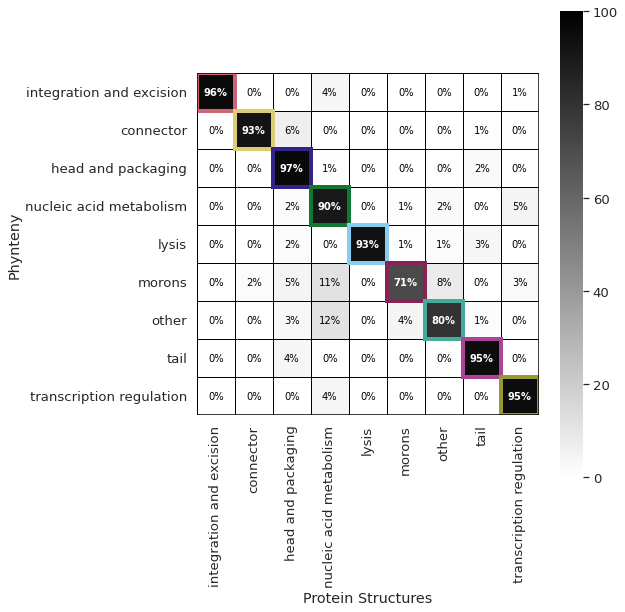

In [592]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix

sns.set(font_scale=1.2)

# Color palette
colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']

# Original long-form labels (used in your data)
original_labels = {
    3: 'DNA, RNA and nucleotide metabolism',
    1: 'connector',
    2: 'head and packaging',
    0: 'integration and excision',
    4: 'lysis',
    5: 'moron, auxiliary metabolic gene and host takeover',
    6: 'other',
    7: 'tail',
    8: 'transcription regulation',
}
ordered_original = [original_labels[i] for i in sorted(original_labels.keys())]

# Shorter display labels for clarity
label_renames = {
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'moron, auxiliary metabolic gene and host takeover': 'morons'
}

# Compute confusion matrix using original labels
cm = confusion_matrix(
    phold_phynteny_compare['phynteny'],
    phold_phynteny_compare['phold'],
    labels=ordered_original
)
cm_df = pd.DataFrame(cm, index=ordered_original, columns=ordered_original)

# Convert to row-wise percentages
cm_percent = cm_df.div(cm_df.sum(axis=1), axis=0) * 100

# Rename for display (after computation)
cm_percent = cm_percent.rename(index=label_renames, columns=label_renames)

# Final ordered labels after renaming
final_labels = [label_renames.get(label, label) for label in ordered_original]

# Plot settings
vmax_cap = 100
text_switch_threshold = 40

# Plot
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(
    cm_percent,
    annot=False,
    fmt='.0f',
    cmap='binary',
    vmin=0,
    vmax=vmax_cap,
    yticklabels=final_labels,
    xticklabels=final_labels,
    cbar=True,
    linewidths=1.0,
    linecolor='black',
    square=True,
    ax=ax
)

# Manually add a rectangle around the whole heatmap
num_labels = len(final_labels)
outer_rect = Rectangle((0, 0), num_labels, num_labels,
                       linewidth=1.5, edgecolor='black',
                       facecolor='none', zorder=4)
ax.add_patch(outer_rect)


# Annotate and outline
for i in range(len(final_labels)):
    for j in range(len(final_labels)):
        val = cm_percent.iloc[i, j]
        text_color = 'white' if val > text_switch_threshold else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j + 0.5, i + 0.5, f"{val:.0f}%",
                ha='center', va='center',
                color=text_color, fontsize=10, fontweight=weight)
    if cm_percent.iloc[i, i] > 0:
        rect = Rectangle((i, i), 1, 1, linewidth=4, edgecolor=colors1[i],
                         facecolor='none', zorder=3)
        ax.add_patch(rect)

plt.ylabel('Phynteny')
plt.xlabel('Protein Structures')
plt.tight_layout()
plt.savefig('../figures/phold_phynteny_confusion_mat.png')
plt.show()


## Pull out some PHROGs that are predicted th most

Make these two separate tables included in the supp info

In [ ]:
# take all that occur at least 100 times
phynteny_phrog_hits = pd.DataFrame.from_dict(Counter(good_phynteny['phrog_id']),orient='index').sort_values(0, ascending=False)
phynteny_phrog_hits = phynteny_phrog_hits[phynteny_phrog_hits[0]>=100]

In [597]:
per_phrog_predictions = pd.DataFrame()
for h in phynteny_phrog_hits[0].iloc[1:].index: 
    hits = good_phynteny[good_phynteny['phrog_id'] == h]
    counts = pd.DataFrame.from_dict(Counter(hits['phynteny_category']), orient='index') 
    counts.columns = [h]
    per_phrog_predictions = pd.concat([per_phrog_predictions, counts], axis=1)
    
per_phrog_predictions = per_phrog_predictions.drop('No_PHROGs_HMM', axis=1).fillna(0)
per_phrog_predictions.T.to_csv('../analysis_data/inphared_data/per_phrog_phynteny_predictions.csv')

In [528]:
per_phrog_predictions.T.iloc[:30]

,"DNA, RNA and nucleotide metabolism",lysis,other,"moron, auxiliary metabolic gene and host takeover",connector,tail,transcription regulation,head and packaging,integration and excision
824,1972.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
600,0.0,1468.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
862,1183.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34481,1144.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,932.0,0.0
420,0.0,0.0,2.0,897.0,0.0,0.0,0.0,0.0,0.0
38319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,787.0,0.0
12751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,724.0,0.0
33534,0.0,638.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
810,0.0,0.0,0.0,0.0,626.0,0.0,0.0,0.0,0.0
